<a href="https://colab.research.google.com/github/harshantla-cloud/BRAIN-TUMOR-DETECTION-VGG16/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Libraries

In [19]:
import os  # For directory and file operations
import numpy as np  # For numerical operations and handling image arrays
import matplotlib.pyplot as plt # Visualization
import random  # For generating random values for augmentation
from PIL import Image, ImageEnhance  # For image processing and enhancement
from tensorflow.keras.preprocessing.image import load_img  # For loading images
from tensorflow.keras.models import Sequential  # For building the model
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  # For model layers
from tensorflow.keras.optimizers import Adam  # For optimizer
from tensorflow.keras.applications import VGG16  # For using VGG16 model
from sklearn.utils import shuffle  # For shuffling the data

# Load Datasets

In [21]:

# Directories for training and testing data
train_dir = '/content/drive/MyDrive/MRI Images/Training/'
test_dir = '/content/drive/MyDrive/MRI Images/Testing/'

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# Data Visualization

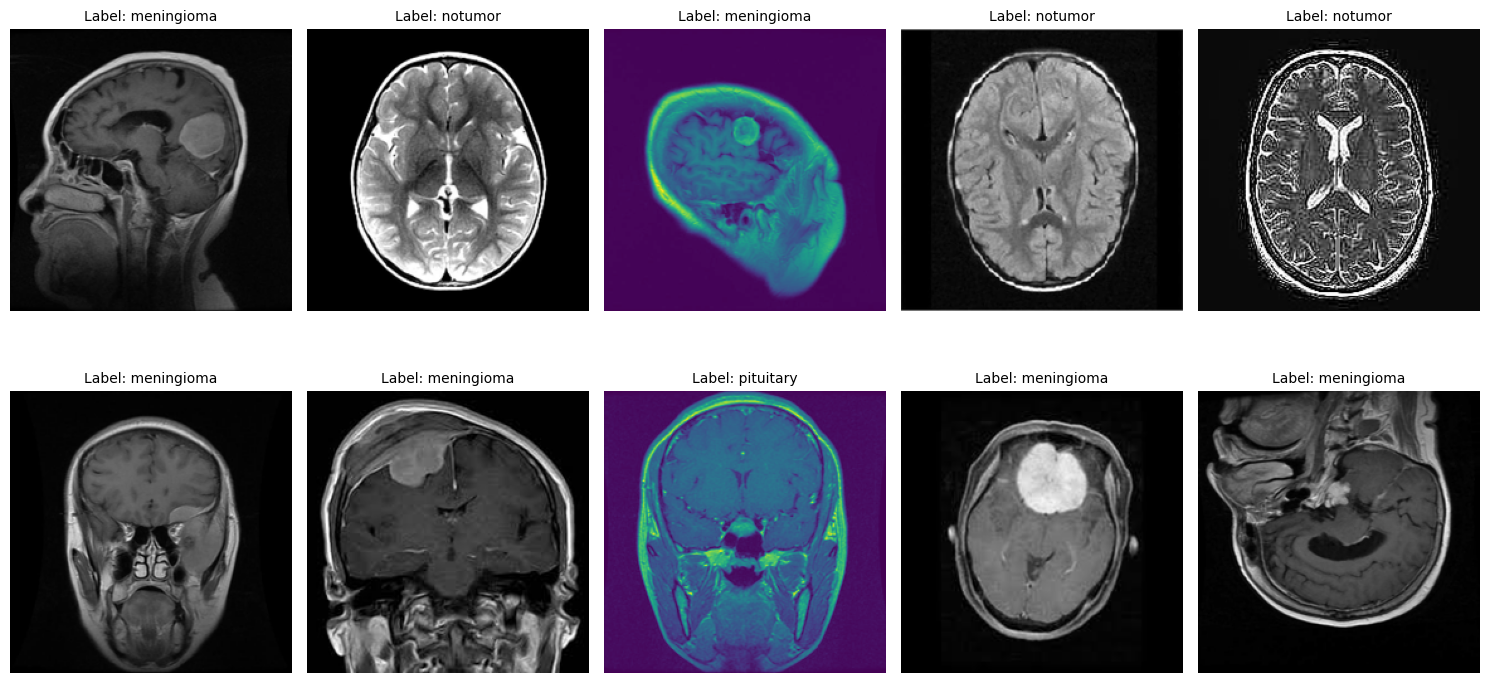

In [24]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    # Load image
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Resize to consistent size

    # Display image
    axes[i].imshow(img)
    axes[i].axis('off')  # Hide axis
    # Display class label in the second row
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

# Image Preprocessing (Helper Functions)

In [ ]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Encode labels
            yield batch_images, batch_labels  # Yield the batch

# MODEL:
# WE ARE USING VGG16 FOR TRANSFER LEARNING.
1. First, the VGG16 model is loaded with input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet'. The input shape is set to match the size of the images in the dataset, which is 128x128 pixels. The include_top parameter is set to False, which means that the final fully-connected layers of VGG16 that perform the classification will not be included. The weights parameter is set to 'imagenet' which means that the model will be pre-trained with a dataset of 1.4 million images called imagenet

2. Next, the for layer in base_model.layers: loop is used to set all layers of the base_model (VGG16) to non-trainable, so that the weights of these layers will not be updated during training.

3. Then, the last three layers of the VGG16 model are set to trainable by using base_model.layers[-2].trainable = True,base_model.layers[-3].trainable = True and base_model.layers[-4].trainable = True

4. After that, a Sequential model is created and the VGG16 model is added to it with model.add(base_model).

5. Next, a Flatten layer is added to the model with model.add(Flatten()) which reshapes the output of the VGG16 model from a 3D tensor to a 1D tensor, so that it can be processed by the next layers of the model.

6. Then, a Dropout layer is added with model.add(Dropout(0.3)) which is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

7. After that, a dense layer is added with 128 neurons and relu activation function is added with model.add(Dense(128, activation='relu')).

8. Next, another Dropout layer is added with model.add(Dropout(0.2))

9. Finally, the output dense layer is added with number of neurons equal to the number of unique labels and 'softmax' activation function is added with model.add(Dense(len(unique_labels), activation='softmax')). The 'softmax' activation function is used to give a probability distribution over the possible classes.

In [ ]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Input layer
model.add(base_model)  # Add VGG16 base model
model.add(Flatten())  # Flatten the output of the base model
model.add(Dropout(0.3))  # Dropout layer for regularization
model.add(Dense(128, activation='relu'))  # Dense layer with ReLU activation
model.add(Dropout(0.2))  # Dropout layer for regularization
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Output layer with softmax activation

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Steps per epoch
epochs = 5

# Train the model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1558s 6s/step - loss: 0.4662 - sparse_categorical_accuracy: 0.8177
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1540s 5s/step - loss: 0.2429 - sparse_categorical_accuracy: 0.9082
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1542s 6s/step - loss: 0.1789 - sparse_categorical_accuracy: 0.9273
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1529s 5s/step - loss: 0.1084 - sparse_categorical_accuracy: 0.9588
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 1532s 5s/step - loss: 0.0921 - sparse_categorical_accuracy: 0.9673


# Train and Val Plots

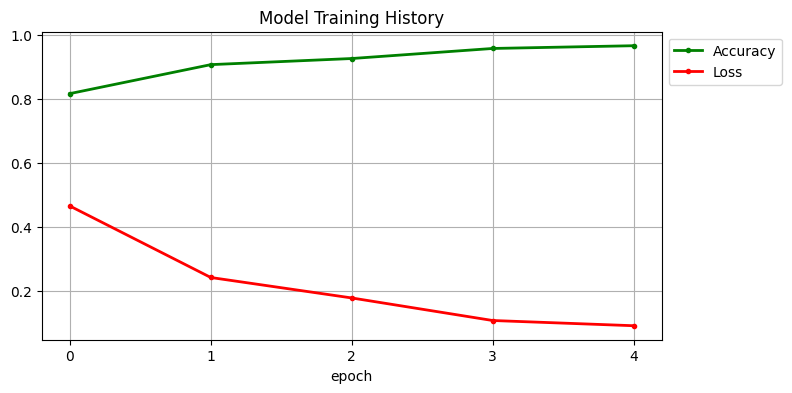

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# Model Classification Report

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 362s 7s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       400
           1       0.99      0.64      0.77       400
           2       0.84      0.89      0.86       400
           3       0.89      0.98      0.93       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.87      1600
weighted avg       0.89      0.88      0.87      1600



# Model Confusion Plot

In [30]:
test_predictions = model.predict(test_generator)

test_labels_encoded = test_generator.classes

print("Predictions shape:", test_predictions.shape)
print("Labels shape:", test_labels_encoded.shape)

50/50 ━━━━━━━━━━━━━━━━━━━━ 458s 9s/step
Predictions shape: (1600, 4)
Labels shape: (1600,)


In [33]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 49 252  64  35]
 [ 21   2 358  19]
 [400   0   0   0]
 [  3   0   2 395]]


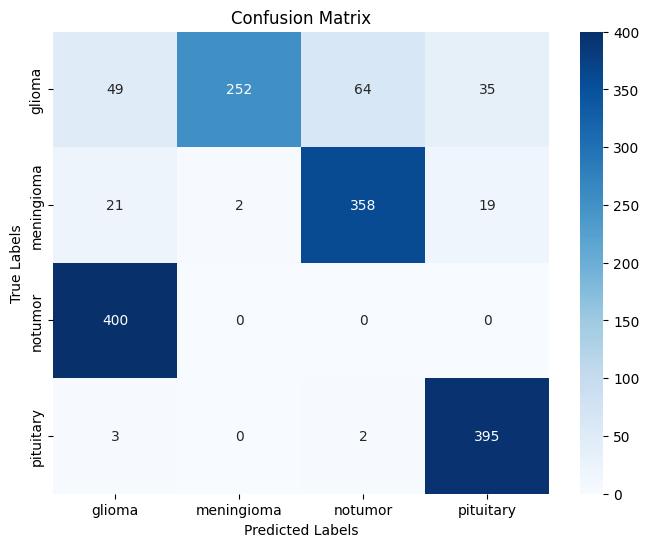

In [36]:
# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))

class_names = list(test_generator.class_indices.keys())

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve Plot

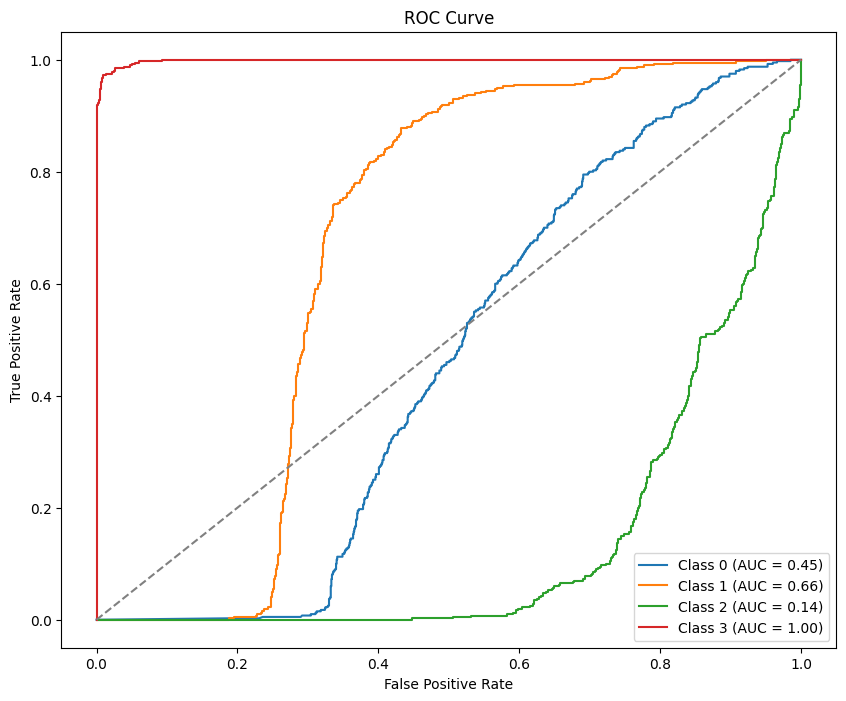

In [38]:
# 4. ROC Curve and AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Number of classes
num_classes = len(test_generator.class_indices)

# Binarize the test labels
test_labels_bin = label_binarize(
    test_labels_encoded,
    classes=np.arange(num_classes)
)

test_predictions_bin = test_predictions

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(
        test_labels_bin[:, i],
        test_predictions_bin[:, i]
    )
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.show()

# Save & Load Model

In [39]:
# Save the entire model
model.save('model.h5')

In [7]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,021,198 (122.15 MB)

 Trainable params: 8,128,644 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 16,257,290 (62.02 MB)

In [29]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith(('.h5', '.keras', '.hdf5')):
            print(os.path.join(root, file))

/content/drive/MyDrive/MRI Images/brain_tumor_model.keras


# Model Load

In [31]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/MRI Images/brain_tumor_model.keras'
)

print("Model loaded successfully!")

Model loaded successfully!


In [32]:
import os

print(os.path.exists('/content/model.h5'))

False


# MRI Tumor Detection System

In [34]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load your trained model
# --------------------------------------------------

model = load_model(
    '/content/drive/MyDrive/MRI Images/brain_tumor_model.keras'
)

print("Model loaded successfully!")

# --------------------------------------------------
# 2. Class labels
# --------------------------------------------------

class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']


# --------------------------------------------------
# 3. Prediction function
# --------------------------------------------------

def detect_and_display(img_path, model, image_size=128):

    try:
        # Load image
        img = load_img(
            img_path,
            target_size=(image_size, image_size)
        )

        # Convert image to array
        img_array = img_to_array(img)

        # Normalize pixel values
        img_array = img_array / 255.0

        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction
        predictions = model.predict(img_array, verbose=0)

        # Get predicted class
        predicted_class_index = np.argmax(predictions[0])

        # Get confidence
        confidence_score = predictions[0][predicted_class_index]

        predicted_class = class_labels[predicted_class_index]

        # Convert "notumor" to user-friendly result
        if predicted_class == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_class}"

        # --------------------------------------------------
        # Display image and result
        # --------------------------------------------------

        plt.figure(figsize=(6, 6))

        plt.imshow(load_img(img_path))
        plt.axis('off')

        plt.title(
            f"{result}\n"
            f"Confidence: {confidence_score * 100:.2f}%"
        )

        plt.show()

        # Print result as well
        print("Predicted Class:", predicted_class)
        print("Result:", result)
        print(f"Confidence: {confidence_score * 100:.2f}%")

    except Exception as e:
        print("Error processing the image:", str(e))

Model loaded successfully!


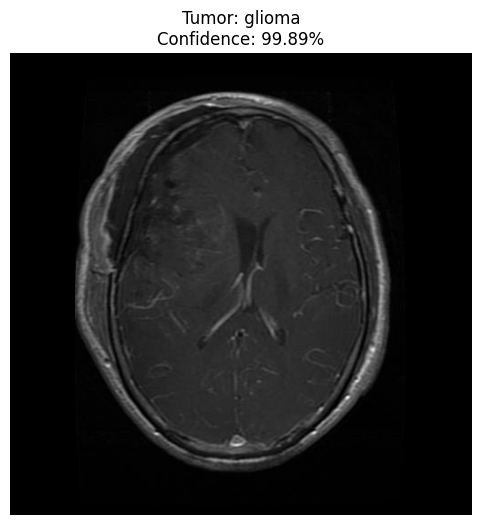

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 99.89%


In [39]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_50.jpg'

detect_and_display(image_path, model)

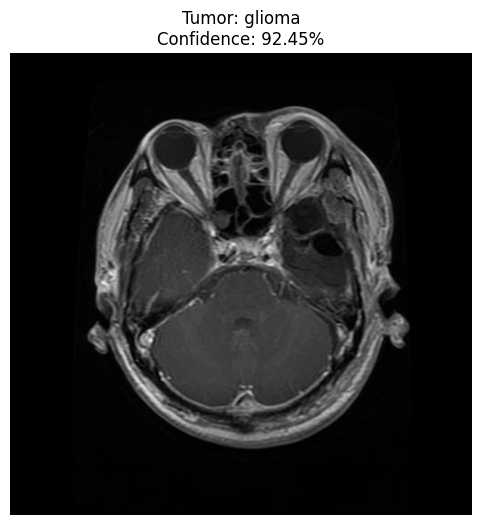

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 92.45%


In [40]:
image_path = '/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_200.jpg'

detect_and_display(image_path, model)


Testing image: Te-gl_1.jpg


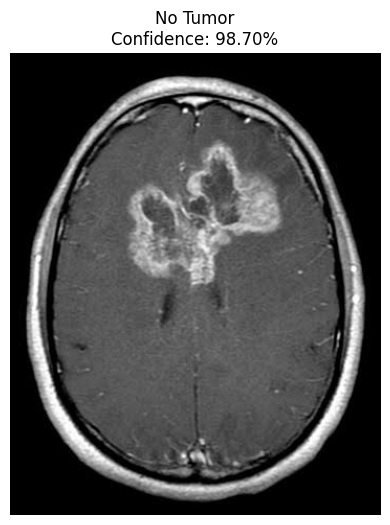

Predicted Class: notumor
Result: No Tumor
Confidence: 98.70%

Testing image: Te-gl_50.jpg


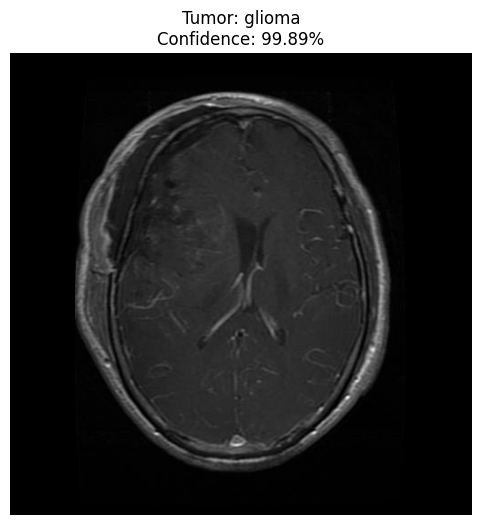

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 99.89%

Testing image: Te-gl_100.jpg


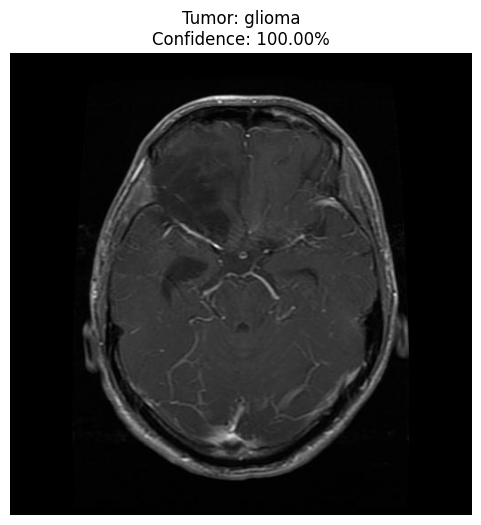

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 100.00%

Testing image: Te-gl_200.jpg


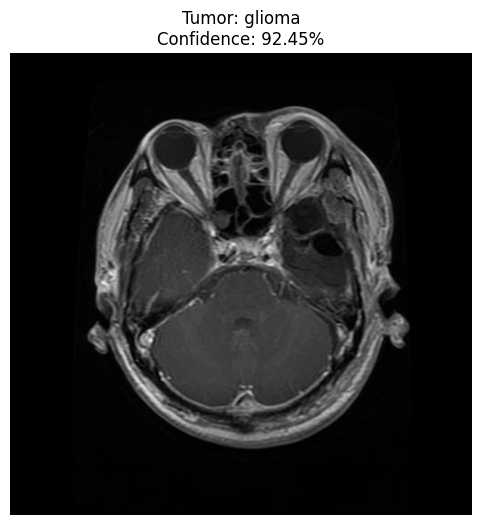

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 92.45%

Testing image: Te-gl_300.jpg


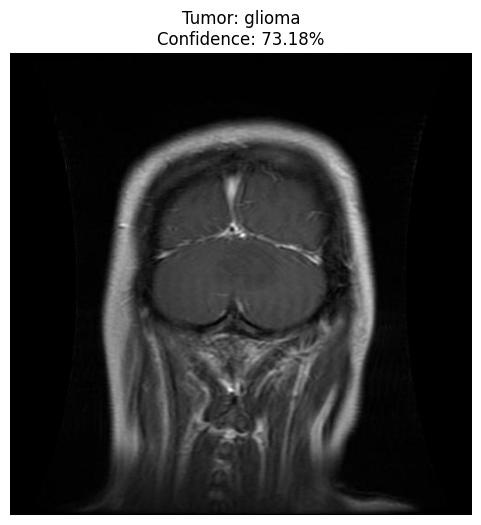

Predicted Class: glioma
Result: Tumor: glioma
Confidence: 73.18%


In [41]:
image_numbers = [1, 50, 100, 200, 300]

for num in image_numbers:
    image_path = f'/content/drive/MyDrive/MRI Images/Testing/glioma/Te-gl_{num}.jpg'

    print(f"\nTesting image: Te-gl_{num}.jpg")
    detect_and_display(image_path, model)